# Expérience 2

### Importation des librairies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math as math
import scipy.stats as stats
from bokeh.colors.named import blueviolet

### Condition initiale

In [2]:
def condition_initiale(betha,rho):
    n=math.sqrt(betha*(rho-1))
    return n
def y_initiale(n): #
    y=n+3
    return y
def z_initiale(rho):
    z=rho-1.0
    return float(z)

### Schéma d'Euler

In [3]:
deltat=0.001
def schema_x(sigma,y,x,deltat):
    x_n=(sigma*(y-x)*deltat)+x
    return x_n
def schema_y(y,x,deltat,rho,z):
    y_n=(((x*(rho-z))-y)*deltat)+y
    return y_n
def schema_z(y,x,deltat,betha,z):
    z_n=(((y*x)-(betha*z))*deltat)+z
    return z_n


### Prévisibilité

In [4]:
def prévisibilité(std,list_1,list_2):
    i=0
    while std > (abs(list_1[i]-list_2[i])): # détermine si la list1-list2 est plus grand que l'écart type
        i=i+1 # ajour
    return i

## 1


###  Solution stationnaire

In [190]:
sigma=10
rho=1.0
betha=2.667
N=2*(10**4)
n=condition_initiale(betha,rho)
t=np.linspace(0,deltat*(N-1),N) # liste du temps pour faire les graphiques
x=n
y=y_initiale(n)
z=z_initiale(rho)
x_list=np.linspace(0,0,N)
y_list=np.linspace(0,0,N)
z_list=np.linspace(0,0,N)
x_list[0]=x
y_list[0]=y
z_list[0]=z
# Calcul de x y z 2x10^4 pas de temps
for i in range(N-1):
    x_n=schema_x(sigma,y,x,deltat)
    y_n=schema_y(y,x,deltat,rho,z)
    z_n=schema_z(y,x,deltat,betha,z)
    x_list[i+1]=x_n
    y_list[i+1]=y_n
    z_list[i+1]=z_n
    x=x_n
    y=y_n
    z=z_n


#### Création des graphiques

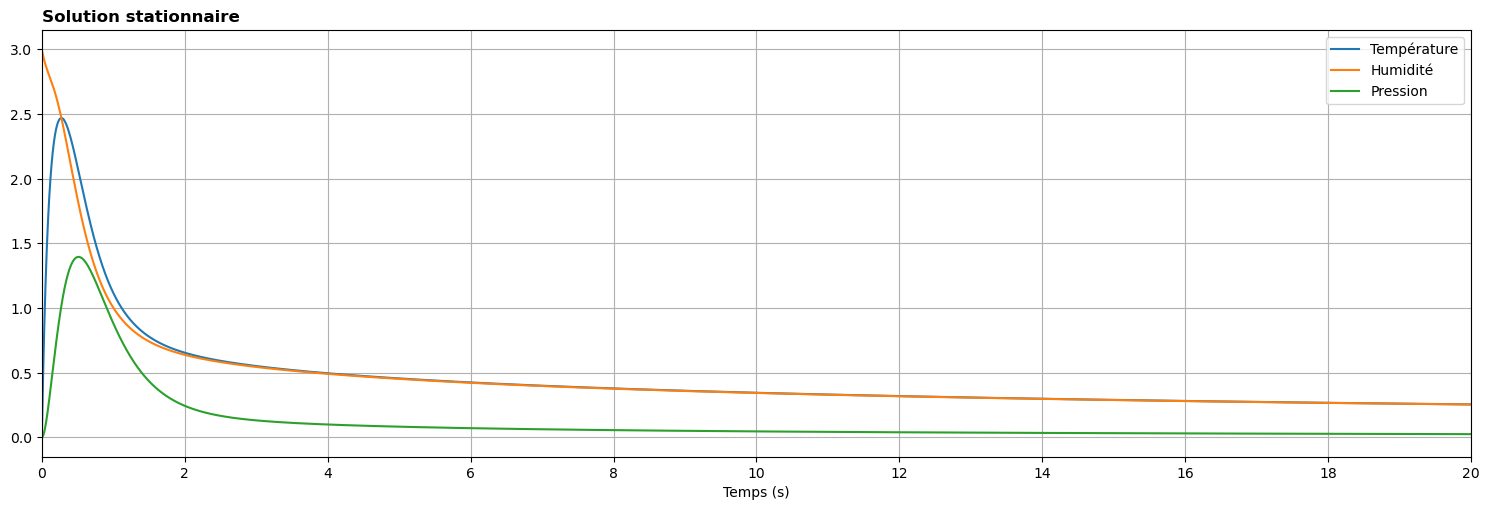

In [191]:
fig, ax=plt.subplots(figsize=(15,5))
ax.plot(t,x_list,label='Température')
ax.plot(t,y_list,label='Humidité')
ax.plot(t,z_list,label='Pression')
ax.legend()
ax.set_title('Solution stationnaire',loc='left',fontweight='bold')
ax.set_xticks([0,2,4,6,8,10,12,14,16,18,20])
ax.set_xlim([0,20])
ax.set_xlabel('Temps (s)')
ax.grid()
plt.tight_layout()
plt.subplots_adjust(top=0.97)
fig.savefig('stationnaire_temps.png',bbox_inches='tight',dpi=500 )

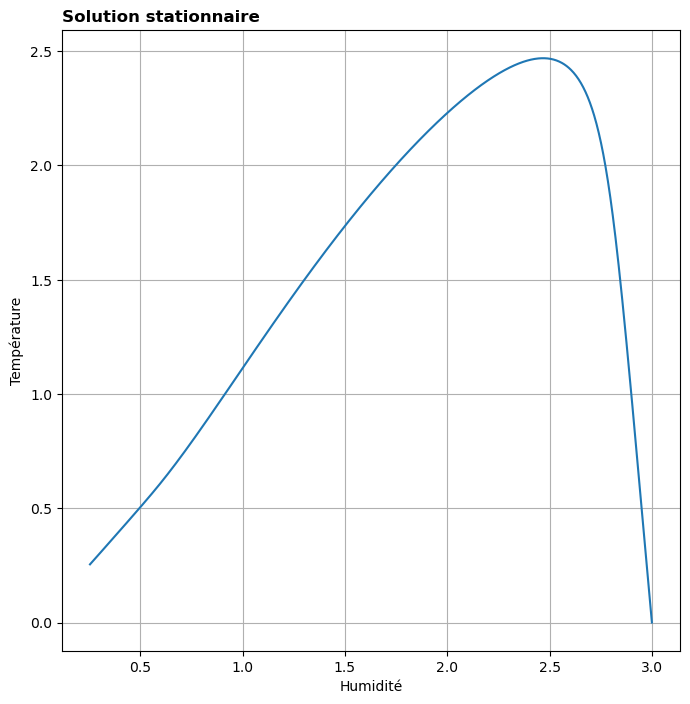

In [123]:
fig, ax=plt.subplots(figsize=(7,7))
ax.plot(y_list,x_list)
ax.set_ylabel('Température')
ax.set_xlabel('Humidité')
ax.set_title('Solution stationnaire',loc='left',fontweight='bold')
ax.grid()
plt.tight_layout()
plt.subplots_adjust(top=0.97)
fig.savefig('Stationnaire_T_H.png', bbox_inches='tight',dpi=500 )


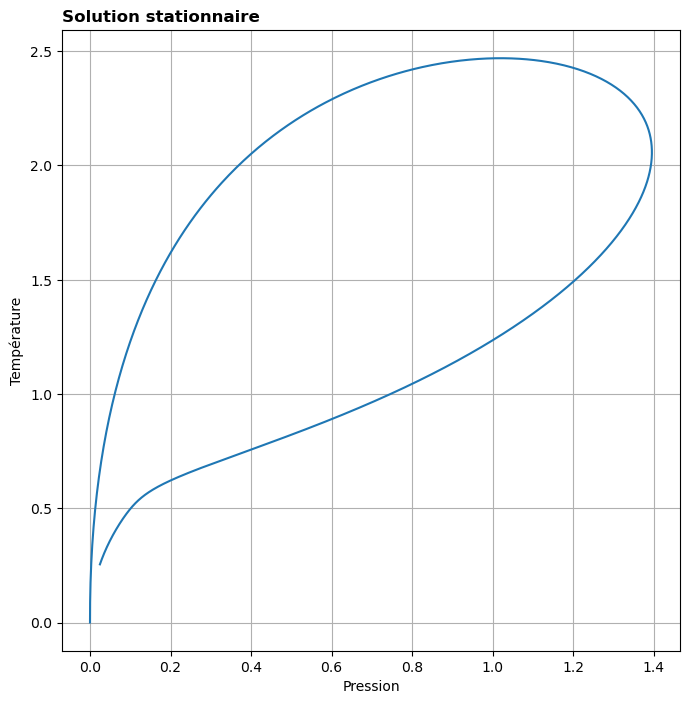

In [124]:
fig, ax = plt.subplots(figsize=(7,7))
ax.plot(z_list, x_list)
ax.set_ylabel('Température')
ax.set_xlabel('Pression')
ax.set_title('Solution stationnaire',loc='left',fontweight='bold')
ax.grid()
plt.tight_layout()
plt.subplots_adjust(top=0.97)
fig.savefig('Stationnaire_T_P.png', bbox_inches='tight',dpi=500 )

### Solution prériodique

In [117]:
sigma=10
rho=350.0
betha=2.667
N=2*(10**4)
n=condition_initiale(betha,rho)
t=np.linspace(0,deltat*(N-1),N) # liste du temps pour faire les graphiques
x=n
y=y_initiale(n)
z=z_initiale(rho)
x_list=np.linspace(0,0,N)
y_list=np.linspace(0,0,N)
z_list=np.linspace(0,0,N)
x_list[0]=x
y_list[0]=y
z_list[0]=z
# Calcul de x y z 2x10^4 pas de temps
for i in range(N-1):
    x_n=schema_x(sigma,y,x,deltat)
    y_n=schema_y(y,x,deltat,rho,z)
    z_n=schema_z(y,x,deltat,betha,z)
    x_list[i+1]=x_n
    y_list[i+1]=y_n
    z_list[i+1]=z_n
    x=x_n
    y=y_n
    z=z_n


#### Créations des graphique

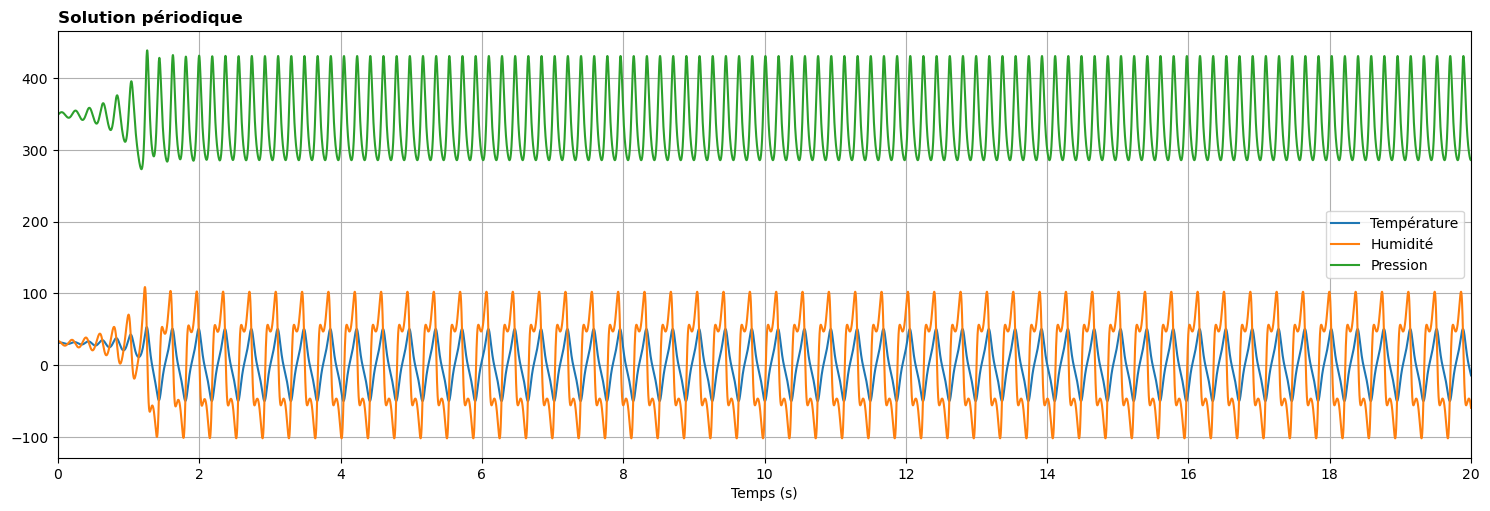

In [70]:
fig, ax=plt.subplots(figsize=(15,5))
ax.plot(t,x_list,label='Température')
ax.plot(t,y_list,label='Humidité')
ax.plot(t,z_list,label='Pression')
ax.legend()
ax.set_title('Solution périodique',loc='left',fontweight='bold')
ax.set_xlabel('Temps (s)')
ax.set_xticks([0,2,4,6,8,10,12,14,16,18,20])
ax.set_xlim([0,20])
ax.grid()
plt.tight_layout()
plt.subplots_adjust(top=0.97)
fig.savefig('Périodique_Temps.png', bbox_inches='tight',dpi=500 )


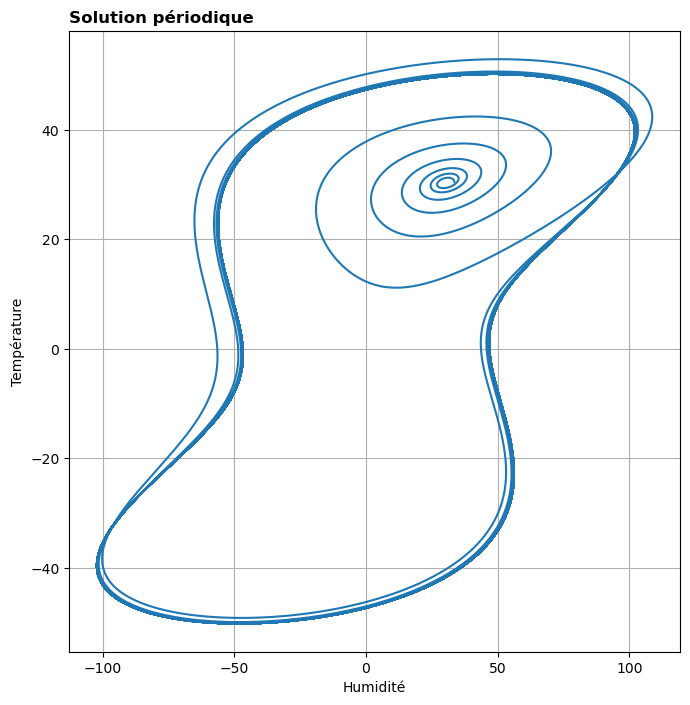

In [118]:
fig,ax=plt.subplots(figsize=(7,7))
ax.plot(y_list,x_list)
ax.set_ylabel('Température')
ax.set_xlabel('Humidité')
ax.set_title('Solution périodique',loc='left',fontweight='bold')
ax.grid()
plt.tight_layout()
plt.subplots_adjust(top=0.97)
fig.savefig('Périodique_T_H.png', bbox_inches='tight',dpi=500 )

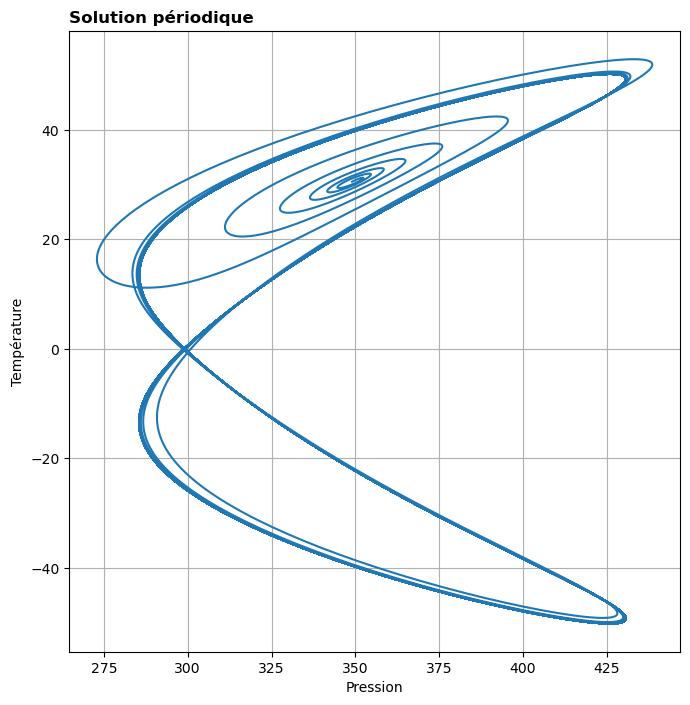

In [120]:

fig, ax = plt.subplots(figsize=(7,7))
ax.plot(z_list, x_list)
ax.set_ylabel('Température')
ax.set_xlabel('Pression')
ax.set_title('Solution périodique',loc='left',fontweight='bold')
ax.grid()
plt.tight_layout()
plt.subplots_adjust(top=0.97)
fig.savefig('Périodique_T_P.png', bbox_inches='tight',dpi=500 )

### Solution chaotique

In [126]:
sigma=10
rho=28.0
betha=2.667
N=2*(10**4)
n=condition_initiale(betha,rho)
t=np.linspace(0,deltat*(N-1),N) # liste du temps pour faire les graphiques
x=n
y=y_initiale(n)
z=z_initiale(rho)
x_list=np.linspace(0,0,N)
y_list=np.linspace(0,0,N)
z_list=np.linspace(0,0,N)
x_list[0]=x
y_list[0]=y
z_list[0]=z
# Calcul de x y z 2x10^4 pas de temps
for i in range(N-1):
    x_n=schema_x(sigma,y,x,deltat)
    y_n=schema_y(y,x,deltat,rho,z)
    z_n=schema_z(y,x,deltat,betha,z)
    x_list[i+1]=x_n
    y_list[i+1]=y_n
    z_list[i+1]=z_n
    x=x_n
    y=y_n
    z=z_n
x_chaotique=x_list
y_chaotique=y_list
z_chaotique=z_list


#### Créations de graphique

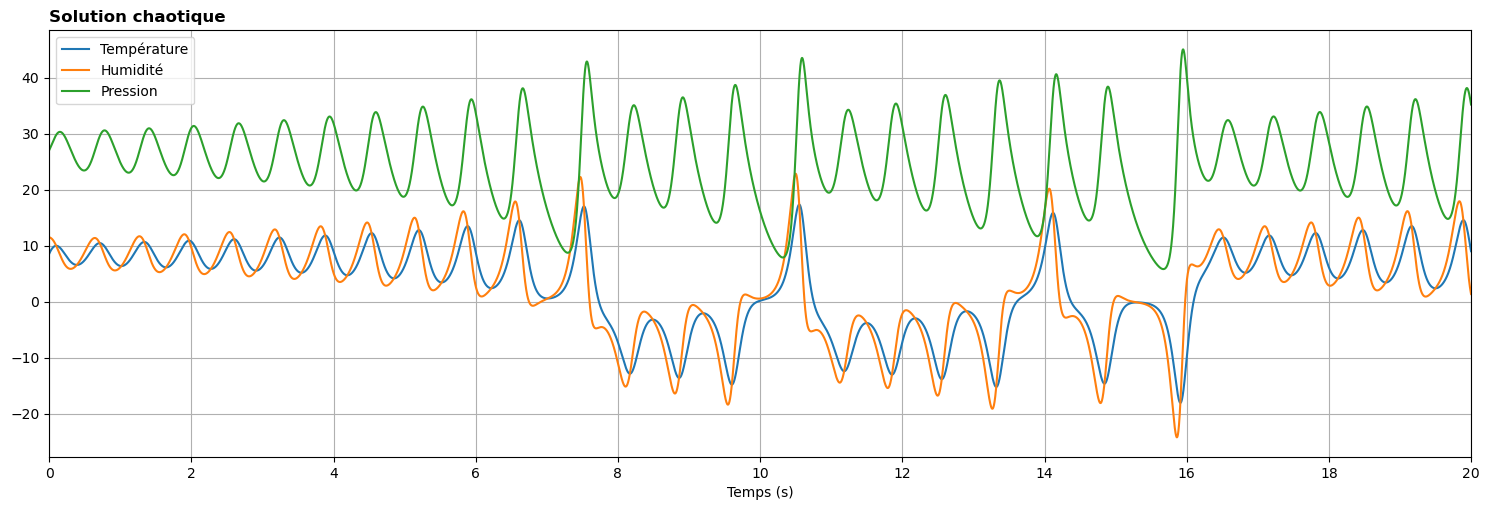

In [74]:
fig, ax=plt.subplots(figsize=(15,5))
ax.plot(t,x_list,label='Température')
ax.plot(t,y_list,label='Humidité')
ax.plot(t,z_list,label='Pression')
ax.legend()
ax.set_xticks([0,2,4,6,8,10,12,14,16,18,20])
ax.set_xlim([0,20])
ax.set_title('Solution chaotique',loc='left',fontweight='bold')
ax.set_xlabel('Temps (s)')
ax.grid()
plt.tight_layout()
plt.subplots_adjust(top=0.97)
fig.savefig('Chaotique_temps.png',bbox_inches='tight',dpi=500 )

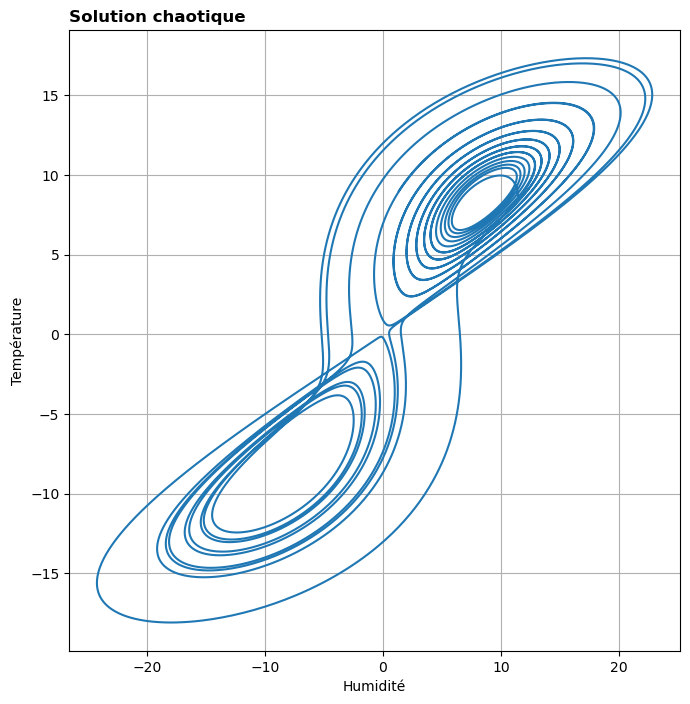

In [128]:
fig, ax=plt.subplots(figsize=(7,7))
ax.plot(y_list,x_list)
ax.set_ylabel('Température')
ax.set_xlabel('Humidité')
ax.set_title('Solution chaotique',loc='left',fontweight='bold')
ax.grid()
plt.tight_layout()
plt.subplots_adjust(top=0.97)
fig.savefig('Chaotique_T_H.png',bbox_inches='tight',dpi=500 )

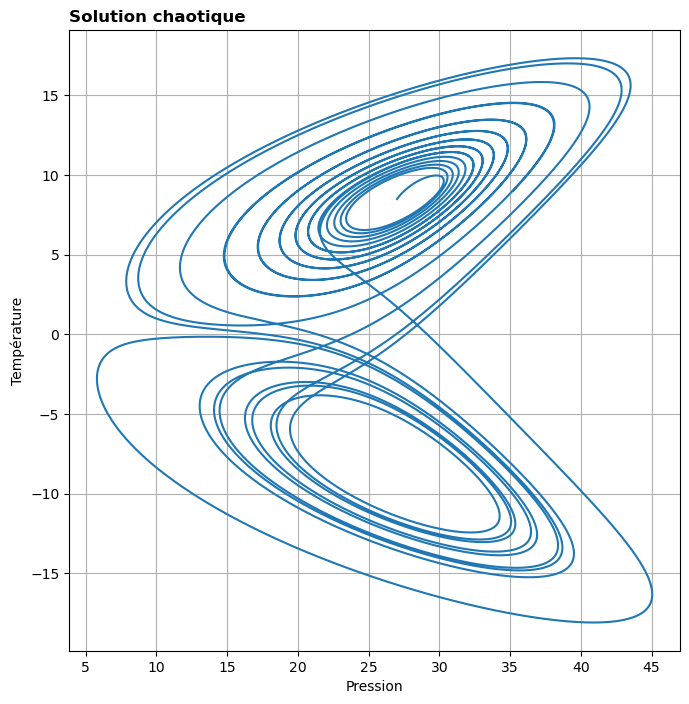

In [129]:
fig, ax = plt.subplots(figsize=(7,7))
ax.plot(z_list, x_list)
ax.set_ylabel('Température')
ax.set_xlabel('Pression')
ax.set_title('Solution chaotique',loc='left',fontweight='bold')
ax.grid()
plt.tight_layout()
plt.subplots_adjust(top=0.97)
fig.savefig('Chaotique_T_P.png',bbox_inches='tight',dpi=500 )

## 2

### Prévisibilité moyenne

In [160]:
epsilon=0.01
sigma=10
rho=28.0
betha=2.667
N=4*(10**4) # nombre de pas de temps
x=n
y=y_initiale(n)
z=z_initiale(rho)
t=np.linspace(0,deltat*(N-1),N)
## Fonction de contrôle
x_list_controle=np.linspace(0,0,N)
y_list_controle=np.linspace(0,0,N)
z_list_controle=np.linspace(0,0,N)
x_list_controle[0]=x
y_list_controle[0]=y
z_list_controle[0]=z
# Calcul de x y z 4x10^4 pas de temps
for i in range(N-1):
    x_n=schema_x(sigma,y,x,deltat)
    y_n=schema_y(y,x,deltat,rho,z)
    z_n=schema_z(y,x,deltat,betha,z)
    x_list_controle[i+1]=x_n
    y_list_controle[i+1]=y_n
    z_list_controle[i+1]=z_n
    x=x_n
    y=y_n
    z=z_n

# Fonction perturbée
n=condition_initiale(betha,rho)
x=n+epsilon
y=y_initiale(n)
z=z_initiale(rho)
x_list_perturbee=np.linspace(0,0,N)
y_list_perturbee=np.linspace(0,0,N)
z_list_perturbee=np.linspace(0,0,N)
x_list_perturbee[0]=x
y_list_perturbee[0]=y
z_list_perturbee[0]=z
# Calcul de x y z 4x10^4 pas de temps
for i in range(N-1):
    x_n=schema_x(sigma,y,x,deltat)
    y_n=schema_y(y,x,deltat,rho,z)
    z_n=schema_z(y,x,deltat,betha,z)
    x_list_perturbee[i+1]=x_n
    y_list_perturbee[i+1]=y_n
    z_list_perturbee[i+1]=z_n
    x=x_n
    y=y_n
    z=z_n

#### Creations des graphiques

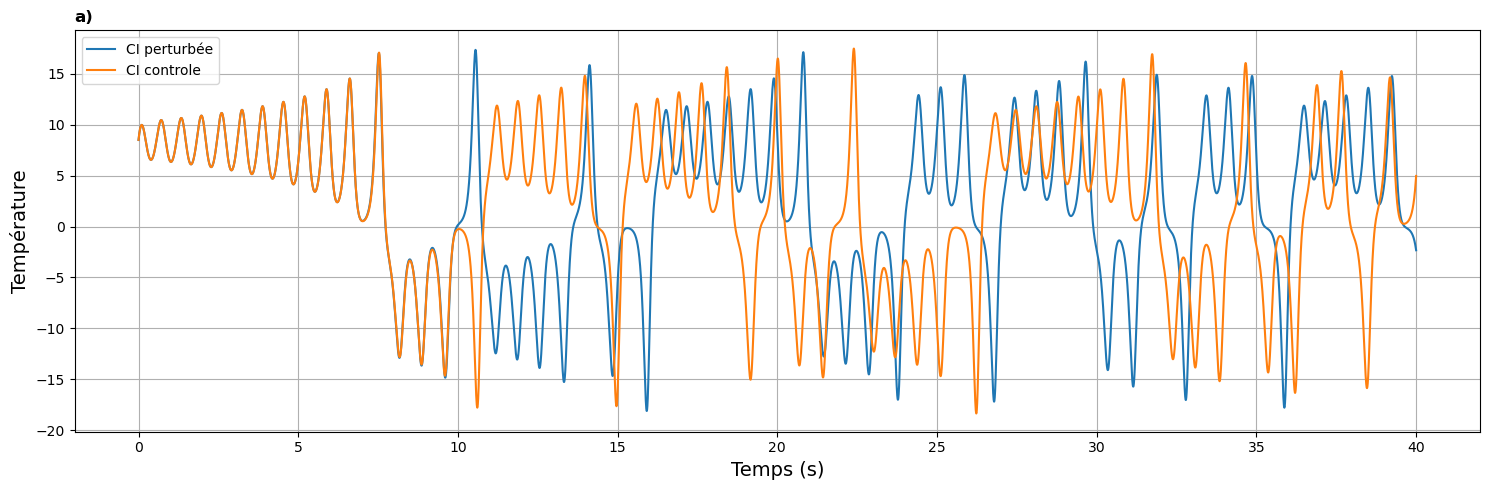

In [106]:
fig, ax=plt.subplots(figsize=(15,5))
ax.plot(t,x_list_controle,label='CI perturbée')
ax.plot(t,x_list_perturbee,label='CI controle')
ax.legend()
ax.set_xlabel('Temps (s)',fontsize=14)
ax.set_ylabel('Température',fontsize=14)
ax.set_title('a)',loc='left',fontweight='bold')
ax.grid()
plt.tight_layout()
fig.savefig('Moyenne_temps_x.png',bbox_inches='tight',dpi=500 )

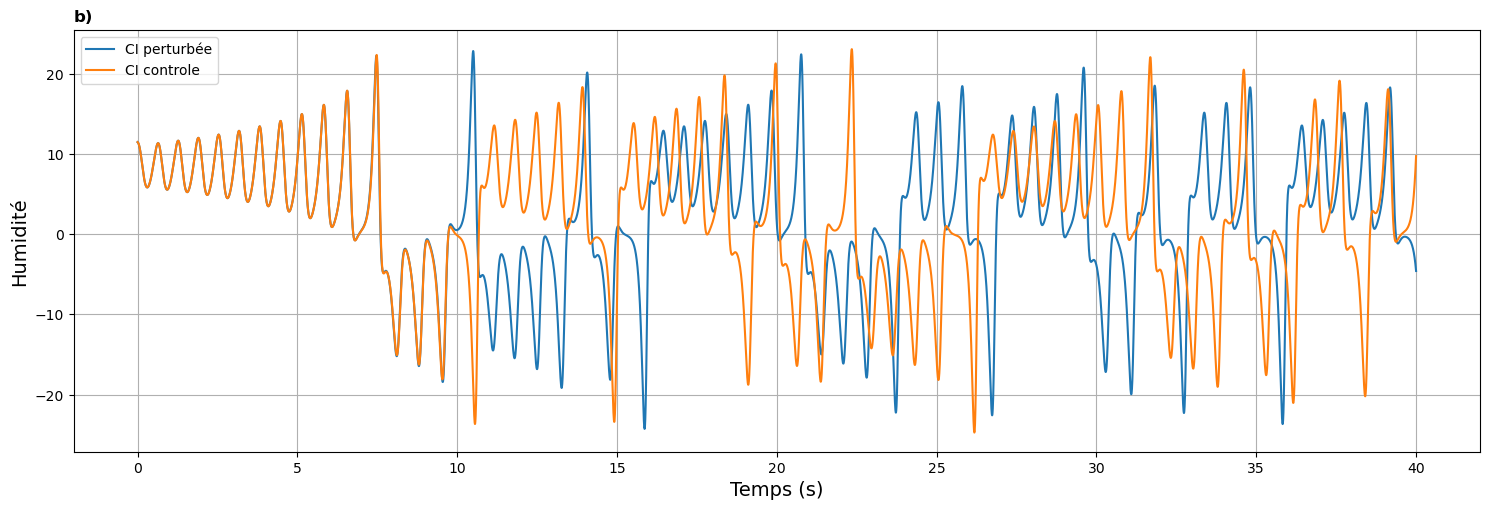

In [107]:
fig, ax=plt.subplots(figsize=(15,5))
ax.plot(t,y_list_controle,label='CI perturbée')
ax.plot(t,y_list_perturbee,label='CI controle')
ax.legend()
ax.set_xlabel('Temps (s)',fontsize=14)
ax.set_ylabel('Humidité',fontsize=14)
ax.set_title('b)',loc='left',fontweight='bold')
ax.grid()
plt.tight_layout()
plt.subplots_adjust(top=0.97)
fig.savefig('Moyenne_temps_y.png',bbox_inches='tight',dpi=500 )

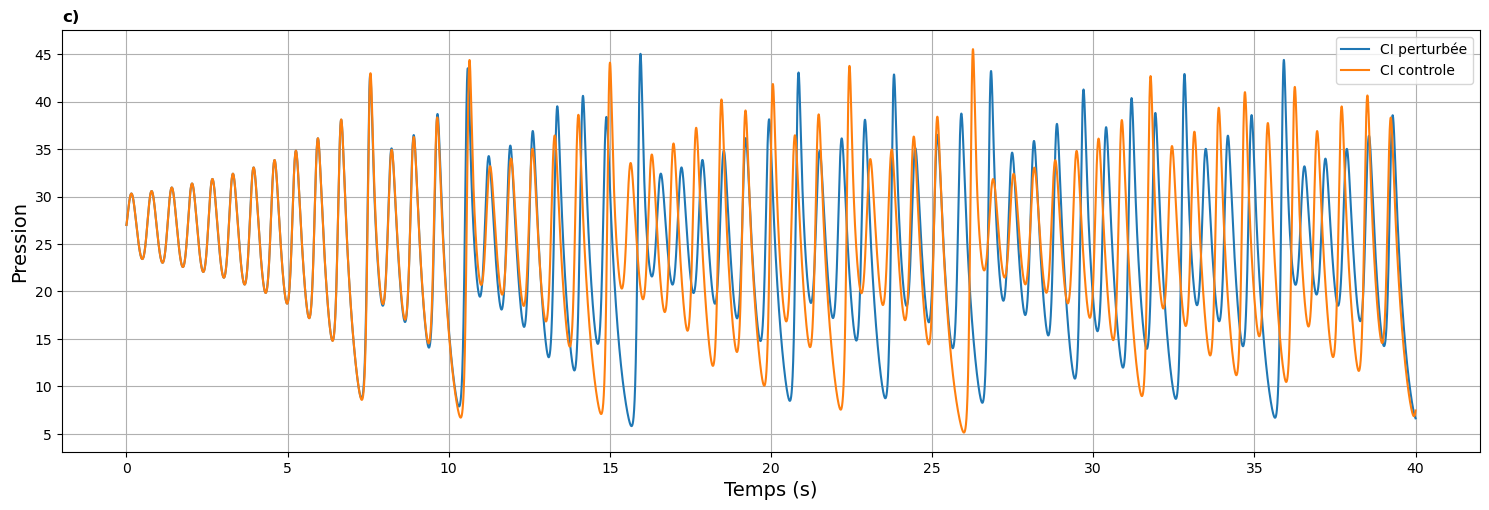

In [108]:
fig, ax=plt.subplots(figsize=(15,5))
ax.plot(t,z_list_controle,label='CI perturbée')
ax.plot(t,z_list_perturbee,label='CI controle')
ax.legend()
ax.set_xlabel('Temps (s)',fontsize=14)
ax.set_ylabel('Pression',fontsize=14)
ax.set_title('c)',loc='left',fontweight='bold')
ax.grid()
plt.tight_layout()
plt.subplots_adjust(top=0.97)
fig.savefig('Moyenne_temps_z.png',bbox_inches='tight',dpi=500 )

#### Écart-type

In [158]:
#calcul des écart type pour x,y et z
std_x=np.std(x_list_controle)
std_y=np.std(y_list_controle)
std_z=np.std(z_list_controle)
print('Écart-type:\nx:',std_x,'\ny:',std_y,'\nz:',std_z)

i_x=prévisibilité(std_x,x_list_perturbee,x_list_controle)
i_y=prévisibilité(std_y,y_list_perturbee,y_list_controle)
i_z=prévisibilité(std_z,z_list_perturbee,z_list_controle)
print('le premier pas de temps t pour lequel la différence absolue entre la solution perturbée et la solution contrôle est plus grande que l’écart type de la variable est a', t[i_x])
print('le premier pas de temps t pour lequel la différence absolue entre la solution perturbée et la solution contrôle est plus grande que l’écart type de la variable est a', t[i_y])
print('le premier pas de temps t pour lequel la différence absolue entre la solution perturbée et la solution contrôle est plus grande que l’écart type de la variable est a', t[i_z])

Écart-type:
x: 7.616714036003292 
y: 8.585069891870733 
z: 8.10125683473358
le premier pas de temps t pour lequel la différence absolue entre la solution perturbée et la solution contrôle est plus grande que l’écart type de la variable est a 10.361
le premier pas de temps t pour lequel la différence absolue entre la solution perturbée et la solution contrôle est plus grande que l’écart type de la variable est a 10.304
le premier pas de temps t pour lequel la différence absolue entre la solution perturbée et la solution contrôle est plus grande que l’écart type de la variable est a 10.461


#### Création de graphique

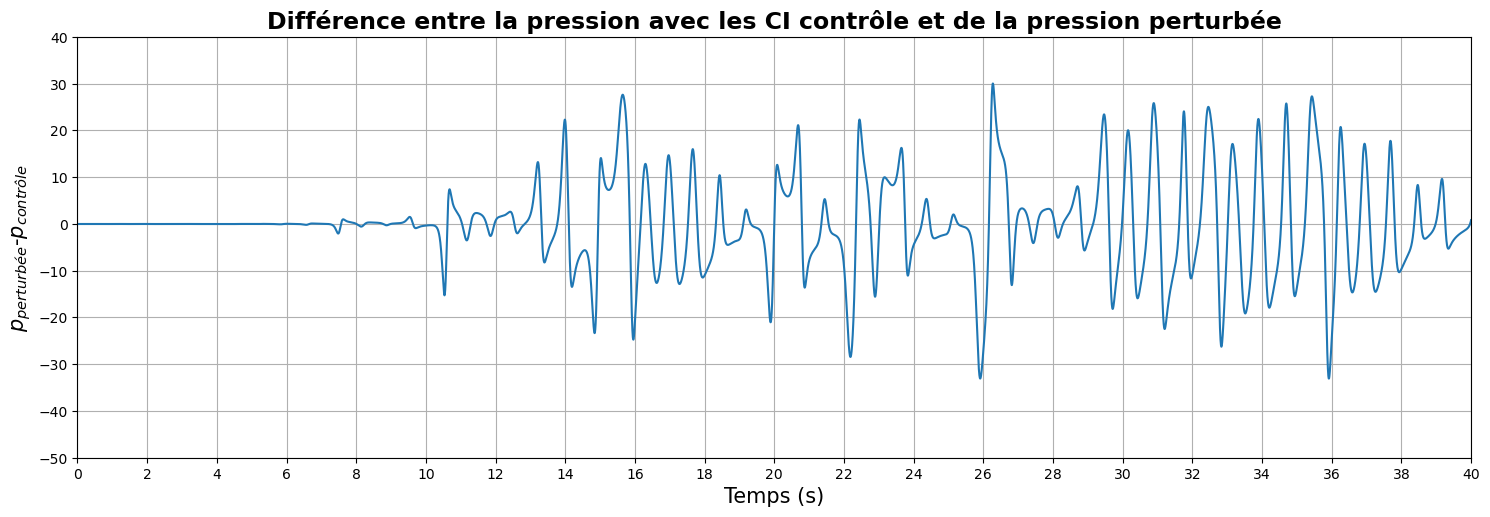

In [187]:
z_difference=z_list_perturbee-z_list_controle
#### Création des graphiques
fig, ax = plt.subplots(figsize=(15,5))
ax.plot(t,z_difference)
ax.set_ylabel('$p_{perturbée}$-$p_{contrôle}$', fontsize=15)
ax.set_xlabel('Temps (s)', fontsize=15)
ax.grid()
ax.set_title('Différence entre la pression avec les CI contrôle et de la pression perturbée',fontweight='bold',fontsize=17)
ax.set_ylim(-50,40)
ax.set_xticks([0,2,4,6,8,10,12,14,16,18,20,22,24,26,28,30,32,34,36,38,40])
ax.set_xlim([0,40])
plt.tight_layout()
plt.subplots_adjust(top=0.97)
fig.savefig('difference_pression.png', bbox_inches='tight', dpi=500)

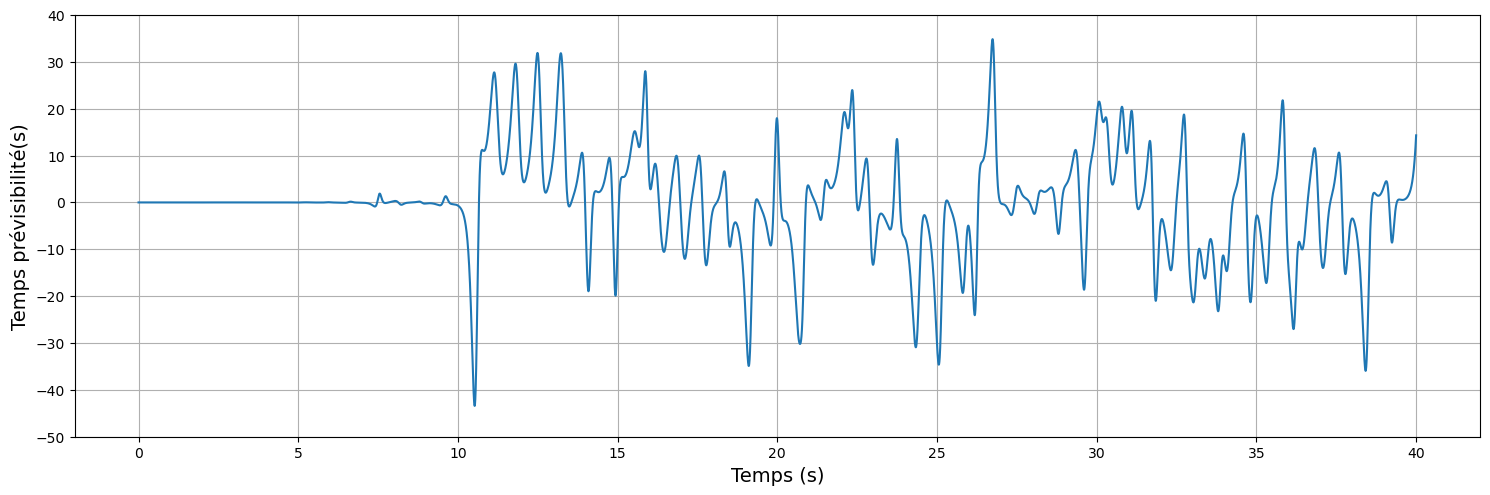

In [179]:
y_difference=y_list_perturbee-y_list_controle
#### Création des graphiques
fig, ax = plt.subplots(figsize=(15,5))
ax.plot(t,y_difference)

ax.set_ylabel('Temps prévisibilité(s)', fontsize=14)
ax.set_xlabel('Temps (s)', fontsize=14)
ax.grid()
ax.set_ylim(-50,40)
plt.tight_layout()
plt.subplots_adjust(top=0.97)
fig.savefig('prévisibilité.png', bbox_inches='tight', dpi=500)

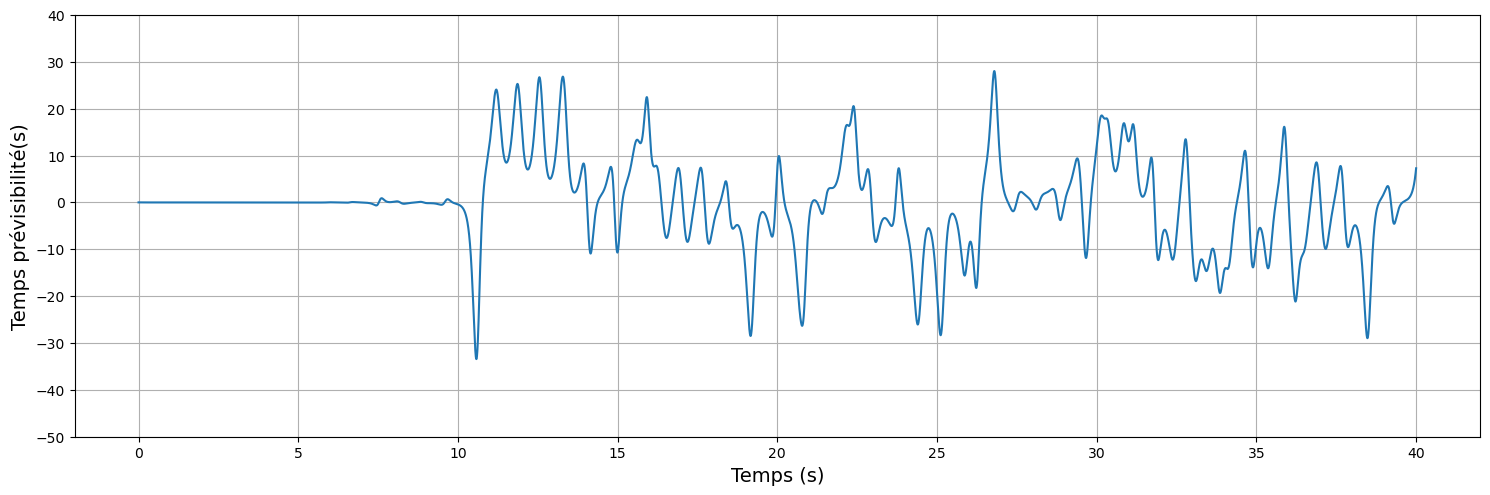

In [178]:
x_difference=x_list_perturbee-x_list_controle
#### Création des graphiques
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(t,x_difference)

ax.set_ylabel('Temps prévisibilité(s)', fontsize=14)
ax.set_xlabel('Temps (s)', fontsize=14)
ax.grid()
ax.set_ylim(-50,40)
plt.tight_layout()
plt.subplots_adjust(top=0.97)
fig.savefig('prévisibilité.png', bbox_inches='tight', dpi=500)

### Prévisibilité selon l'incertitude observationnel

In [147]:
sigma=10
rho=28.0
betha=2.667
N=4*(10**4)
epsilon_1=0.000001
epsilon_2=0.00001
epsilon_3=0.0001
epsilon_4=0.001
epsilon_5=0.01
epsilon_6=0.1
n=condition_initiale(betha,rho)
t=np.linspace(0,deltat*(N-1),N) # liste du temps pour faire les graphiques
x_1=n+epsilon_1
x_2=n+epsilon_2
x_3=n+epsilon_3
x_4=n+epsilon_4
x_5=n+epsilon_5
x_6=n+epsilon_6


x_list_1=np.linspace(0,0,N)
y_list_1=np.linspace(0,0,N)
z_list_1=np.linspace(0,0,N)

x_list_2=np.linspace(0,0,N)
y_list_2=np.linspace(0,0,N)
z_list_2=np.linspace(0,0,N)

x_list_3=np.linspace(0,0,N)
y_list_3=np.linspace(0,0,N)
z_list_3=np.linspace(0,0,N)

x_list_4=np.linspace(0,0,N)
y_list_4=np.linspace(0,0,N)
z_list_4=np.linspace(0,0,N)

x_list_5=np.linspace(0,0,N)
y_list_5=np.linspace(0,0,N)
z_list_5=np.linspace(0,0,N)

x_list_6=np.linspace(0,0,N)
y_list_6=np.linspace(0,0,N)
z_list_6=np.linspace(0,0,N)

x_list_1[0]=x_1
x_list_2[0]=x_2
x_list_3[0]=x_3
x_list_4[0]=x_4
x_list_5[0]=x_5
x_list_6[0]=x_6

y=y_initiale(n)
z=z_initiale(rho)
y_list_1[0]=y
z_list_1[0]=z
y_list_2[0]=y
z_list_2[0]=z
y_list_3[0]=y
z_list_3[0]=z
y_list_4[0]=y
z_list_4[0]=z
y_list_5[0]=y
z_list_5[0]=z
y_list_6[0]=y
z_list_6[0]=z

# Calcul de x y z 2x10^4 pas de temps
x=x_1
for i in range(N-1):
    x_n=schema_x(sigma,y,x,deltat)
    y_n=schema_y(y,x,deltat,rho,z)
    z_n=schema_z(y,x,deltat,betha,z)
    x_list_1[i+1]=x_n
    y_list_1[i+1]=y_n
    z_list_1[i+1]=z_n
    x=x_n
    y=y_n
    z=z_n

x=x_2
y=y_initiale(n)
z=z_initiale(rho)
for i in range(N-1):
    x_n=schema_x(sigma,y,x,deltat)
    y_n=schema_y(y,x,deltat,rho,z)
    z_n=schema_z(y,x,deltat,betha,z)
    x_list_2[i+1]=x_n
    y_list_2[i+1]=y_n
    z_list_2[i+1]=z_n
    x=x_n
    y=y_n
    z=z_n

x=x_3
y=y_initiale(n)
z=z_initiale(rho)
for i in range(N-1):
    x_n=schema_x(sigma,y,x,deltat)
    y_n=schema_y(y,x,deltat,rho,z)
    z_n=schema_z(y,x,deltat,betha,z)
    x_list_3[i+1]=x_n
    y_list_3[i+1]=y_n
    z_list_3[i+1]=z_n
    x=x_n
    y=y_n
    z=z_n

x=x_4
y=y_initiale(n)
z=z_initiale(rho)
for i in range(N-1):
    x_n=schema_x(sigma,y,x,deltat)
    y_n=schema_y(y,x,deltat,rho,z)
    z_n=schema_z(y,x,deltat,betha,z)
    x_list_4[i+1]=x_n
    y_list_4[i+1]=y_n
    z_list_4[i+1]=z_n
    x=x_n
    y=y_n
    z=z_n

x=x_5
y=y_initiale(n)
z=z_initiale(rho)
for i in range(N-1):
    x_n=schema_x(sigma,y,x,deltat)
    y_n=schema_y(y,x,deltat,rho,z)
    z_n=schema_z(y,x,deltat,betha,z)
    x_list_5[i+1]=x_n
    y_list_5[i+1]=y_n
    z_list_5[i+1]=z_n
    x=x_n
    y=y_n
    z=z_n

x=x_6
y=y_initiale(n)
z=z_initiale(rho)
for i in range(N-1):
    x_n=schema_x(sigma,y,x,deltat)
    y_n=schema_y(y,x,deltat,rho,z)
    z_n=schema_z(y,x,deltat,betha,z)
    x_list_6[i+1]=x_n
    y_list_6[i+1]=y_n
    z_list_6[i+1]=z_n
    x=x_n
    y=y_n
    z=z_n


#### Calcul de la prévisibilité

In [148]:
#calcul des écart type pour x,y et z
std_x_1=np.std(x_list_controle)

i_1=prévisibilité(std_x_1,x_list_1,x_list_controle)
i_2=prévisibilité(std_x_1,x_list_2,x_list_controle)
i_3=prévisibilité(std_x_1,x_list_3,x_list_controle)
i_4=prévisibilité(std_x_1,x_list_4,x_list_controle)
i_5=prévisibilité(std_x_1,x_list_5,x_list_controle)
i_6=prévisibilité(std_x_1,x_list_6,x_list_controle)

temps=[t[i_1],t[i_2],t[i_3],t[i_4],t[i_5],t[i_6]]
magnitude=[epsilon_1,epsilon_2,epsilon_3,epsilon_4,epsilon_5,epsilon_6]

#### Création des graphiques

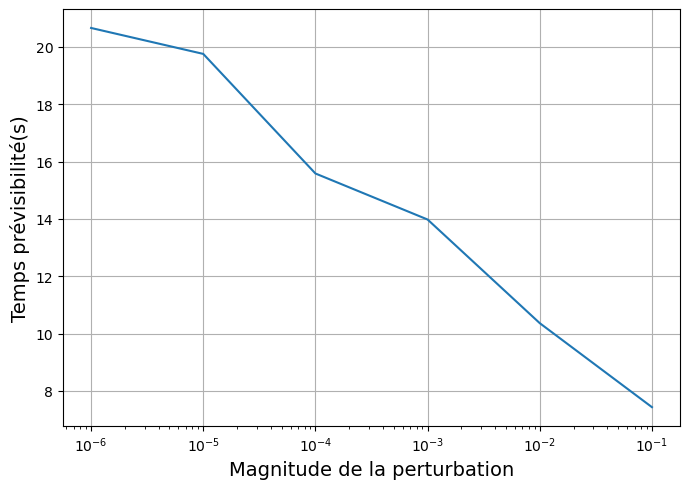

In [150]:
fig, ax=plt.subplots(figsize=(7,5))
ax.plot(magnitude,temps)
ax.set_xscale("log")
ax.set_ylabel('Temps prévisibilité(s)',fontsize=14)
ax.set_xlabel('Magnitude de la perturbation',fontsize=14)
ax.grid()
plt.tight_layout()
plt.subplots_adjust(top=0.97)
fig.savefig('prévisibilité.png',bbox_inches='tight',dpi=500 )

### Prévisibilité selon le « régime de temps »

In [151]:
sigma=10
rho=28.0
betha=2.667
N=4*(10**4)
epsilon_1=0.01

n=condition_initiale(betha,rho)
t=np.linspace(0,deltat*(N-1),N) # liste du temps pour faire les graphiques
x_1=n-2
x_1p=x_1+epsilon_1
x_2=n-4
x_2p=x_2+epsilon_1
x_3=n-6
x_3p=x_3+epsilon_1
x_4=n-8
x_4p=x_4+epsilon_1

x_ini=[x_1,x_2,x_3,x_4]
y_1=n+1
y_2=n-1
y_3=n-3
y_4=n-5
z=z_initiale(rho)

x_list_1=np.linspace(0,0,N)
x_list_1p=np.linspace(0,0,N) # perturbée
y_list_1=np.linspace(0,0,N)
y_list_1p=np.linspace(0,0,N)
z_list_1=np.linspace(0,0,N)
z_list_1p=np.linspace(0,0,N)

x_list_2=np.linspace(0,0,N)
x_list_2p=np.linspace(0,0,N)
y_list_2=np.linspace(0,0,N)
y_list_2p=np.linspace(0,0,N)
z_list_2=np.linspace(0,0,N)
z_list_2p=np.linspace(0,0,N)

x_list_3=np.linspace(0,0,N)
x_list_3p=np.linspace(0,0,N)
y_list_3=np.linspace(0,0,N)
y_list_3p=np.linspace(0,0,N)
z_list_3=np.linspace(0,0,N)
z_list_3p=np.linspace(0,0,N)

x_list_4=np.linspace(0,0,N)
x_list_4p=np.linspace(0,0,N)
y_list_4=np.linspace(0,0,N)
y_list_4p=np.linspace(0,0,N)
z_list_4=np.linspace(0,0,N)
z_list_4p=np.linspace(0,0,N)

x_list_1[0]=x_1
x_list_1p[0]=x_1p
x_list_2[0]=x_2
x_list_2p[0]=x_2p
x_list_3[0]=x_3
x_list_3p[0]=x_3p
x_list_4[0]=x_4
x_list_4p[0]=x_4p

y_list_1[0]=y_1
z_list_1[0]=z
y_list_1p[0]=y_1
z_list_1p[0]=z

y_list_2[0]=y_2
y_list_2p[0]=y_2
z_list_2[0]=z
z_list_2p[0]=z

y_list_3[0]=y_3
y_list_3p[0]=y_2
z_list_3[0]=z
z_list_3p[0]=z

y_list_4[0]=y_4
y_list_4p[0]=y_2
z_list_4[0]=z
z_list_4p[0]=z

# Calcul de x y z 2x10^4 pas de temps
x=x_1
y=y_1
z=z_initiale(rho)
for i in range(N-1):
    x_n=schema_x(sigma,y,x,deltat)
    y_n=schema_y(y,x,deltat,rho,z)
    z_n=schema_z(y,x,deltat,betha,z)
    x_list_1[i+1]=x_n
    y_list_1[i+1]=y_n
    z_list_1[i+1]=z_n
    x=x_n
    y=y_n
    z=z_n

x=x_1p
y=y_1
z=z_initiale(rho)
for i in range(N-1):
    x_n=schema_x(sigma,y,x,deltat)
    y_n=schema_y(y,x,deltat,rho,z)
    z_n=schema_z(y,x,deltat,betha,z)
    x_list_1p[i+1]=x_n
    y_list_1p[i+1]=y_n
    z_list_1p[i+1]=z_n
    x=x_n
    y=y_n
    z=z_n

x=x_2
y=y_2
z=z_initiale(rho)
for i in range(N-1):
    x_n=schema_x(sigma,y,x,deltat)
    y_n=schema_y(y,x,deltat,rho,z)
    z_n=schema_z(y,x,deltat,betha,z)
    x_list_2[i+1]=x_n
    y_list_2[i+1]=y_n
    z_list_2[i+1]=z_n
    x=x_n
    y=y_n
    z=z_n

x=x_2p
y=y_2
z=z_initiale(rho)
for i in range(N-1):
    x_n=schema_x(sigma,y,x,deltat)
    y_n=schema_y(y,x,deltat,rho,z)
    z_n=schema_z(y,x,deltat,betha,z)
    x_list_2p[i+1]=x_n
    y_list_2p[i+1]=y_n
    z_list_2p[i+1]=z_n
    x=x_n
    y=y_n
    z=z_n

x=x_3
y=y_3
z=z_initiale(rho)
for i in range(N-1):
    x_n=schema_x(sigma,y,x,deltat)
    y_n=schema_y(y,x,deltat,rho,z)
    z_n=schema_z(y,x,deltat,betha,z)
    x_list_3[i+1]=x_n
    y_list_3[i+1]=y_n
    z_list_3[i+1]=z_n
    x=x_n
    y=y_n
    z=z_n

x=x_3p
y=y_3
z=z_initiale(rho)
for i in range(N-1):
    x_n=schema_x(sigma,y,x,deltat)
    y_n=schema_y(y,x,deltat,rho,z)
    z_n=schema_z(y,x,deltat,betha,z)
    x_list_3p[i+1]=x_n
    y_list_3p[i+1]=y_n
    z_list_3p[i+1]=z_n
    x=x_n
    y=y_n
    z=z_n

x=x_4
y=y_4
z=z_initiale(rho)
for i in range(N-1):
    x_n=schema_x(sigma,y,x,deltat)
    y_n=schema_y(y,x,deltat,rho,z)
    z_n=schema_z(y,x,deltat,betha,z)
    x_list_4[i+1]=x_n
    y_list_4[i+1]=y_n
    z_list_4[i+1]=z_n
    x=x_n
    y=y_n
    z=z_n

x=x_4p
y=y_4
z=z_initiale(rho)
for i in range(N-1):
    x_n=schema_x(sigma,y,x,deltat)
    y_n=schema_y(y,x,deltat,rho,z)
    z_n=schema_z(y,x,deltat,betha,z)
    x_list_4p[i+1]=x_n
    y_list_4p[i+1]=y_n
    z_list_4p[i+1]=z_n
    x=x_n
    y=y_n
    z=z_n


In [152]:
# Calcul de la prévisibilité
#calcul des écarts type pour x,y et z
std_x_1=np.std(x_list_1)
std_x_2=np.std(x_list_2)
std_x_3=np.std(x_list_3)
std_x_4=np.std(x_list_4)

#Pour 1
i_1=prévisibilité(std_x_1,x_list_1,x_list_1p)
i_2=prévisibilité(std_x_2,x_list_2,x_list_2p)
i_3=prévisibilité(std_x_3,x_list_3,x_list_3p)
i_4=prévisibilité(std_x_4,x_list_4,x_list_4p)
magnitude = [t[i_1],t[i_2],t[i_3],t[i_4]]

#### Créations des graphique

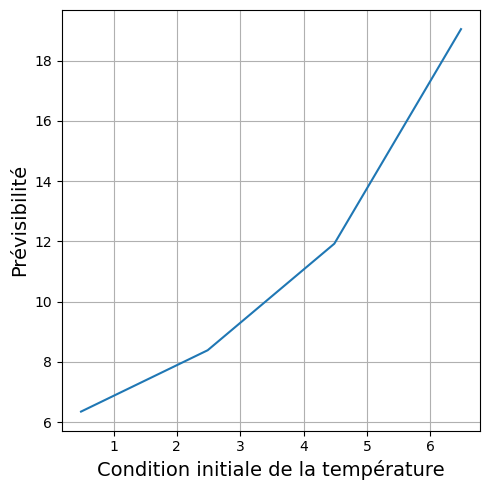

In [196]:
fig, ax=plt.subplots(figsize=(5,5))
ax.plot(x_ini,magnitude)
ax.set_ylabel('Prévisibilité',fontsize=14)
ax.set_xlabel('Condition initiale de la température',fontsize=14)
ax.grid()
plt.tight_layout()
plt.subplots_adjust(top=0.97)
fig.savefig('condition_initiale.png',bbox_inches='tight',dpi=500)

##  3

### Le climat du système chaotique

In [192]:
sigma=10
rho=28.0
betha=2.667
N=(10**4)
epsilon_1=0.01

n=condition_initiale(betha,rho)
t=np.linspace(0,deltat*(N-1),N) # liste du temps pour faire les graphiques
x_1=n
x_2=n+epsilon_1

x_list_1=np.linspace(0,0,N)
y_list_1=np.linspace(0,0,N)
z_list_1=np.linspace(0,0,N)

x_list_2=np.linspace(0,0,N)
y_list_2=np.linspace(0,0,N)
z_list_2=np.linspace(0,0,N)

x_list_1[0]=x_1
x_list_2[0]=x_2

y_list_1[0]=y_initiale(n)
z_list_1[0]=z_initiale(rho)

y_list_2[0]=y_initiale(n)
z_list_2[0]=z_initiale(rho)

# Calcul de x y z 2x10^4 pas de temps
x=x_1
y=y_initiale(n)
z=z_initiale(rho)
for i in range(N-1):
    x_n=schema_x(sigma,y,x,deltat)
    y_n=schema_y(y,x,deltat,rho,z)
    z_n=schema_z(y,x,deltat,betha,z)
    x_list_1[i+1]=x_n
    y_list_1[i+1]=y_n
    z_list_1[i+1]=z_n
    x=x_n
    y=y_n
    z=z_n

x=x_2
y=y_initiale(n)
z=z_initiale(rho)
for i in range(N-1):
    x_n=schema_x(sigma,y,x,deltat)
    y_n=schema_y(y,x,deltat,rho,z)
    z_n=schema_z(y,x,deltat,betha,z)
    x_list_2[i+1]=x_n
    y_list_2[i+1]=y_n
    z_list_2[i+1]=z_n
    x=x_n
    y=y_n
    z=z_n


### Exploration visuelle des différences

In [145]:
def val_min(val_1,val_2):
    if val_1>val_2:
        return val_2
    else:
        return val_1

def val_max(val_1,val_2):
    if val_1<val_2:
        return val_2
    else:
        return val_1
classe=50
min(x_list_1)
min_x=val_min(min(x_list_2),min(x_list_1))
min_y=val_min(min(y_list_2),min(y_list_1))
min_z=val_min(min(z_list_2),min(z_list_1))
max_x=val_max(max(x_list_2),max(x_list_1))
max_y=val_max(max(y_list_2),max(y_list_1))
max_z=val_max(max(z_list_2),max(z_list_1))

logbin_x= np.linspace(min_x,max_x,classe+1)
logbin_y= np.linspace(min_y,max_y,classe+1)
logbin_z= np.linspace(min_z,max_z,classe+1)

#### Créations des graphiques

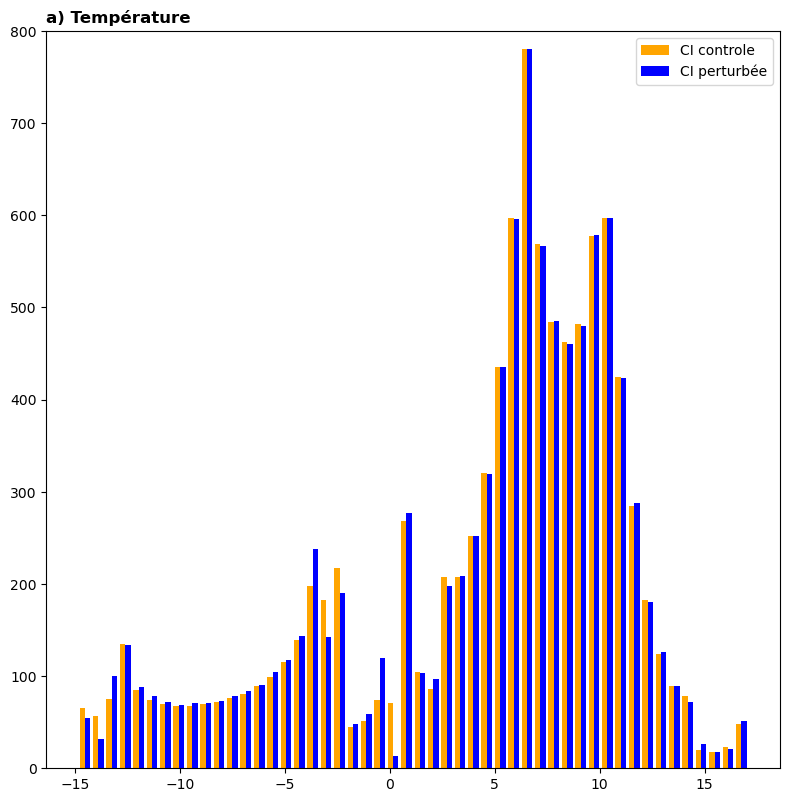

In [142]:
fig,ax=plt.subplots(figsize=(8,8))
label=['CI controle','CI perturbée']
color=['orange','blue']
ax.hist([x_list_1,x_list_2],bins=logbin_x,label=label,histtype='bar',stacked=False,color=color)
#ax.hist(x_list_2,bins=logbin_x,label='CI perturbée',histtype='barstacked')
ax.set_title('a) Température',loc='left',fontweight='bold')
plt.legend()
ax.set_ylim(0,800)
plt.tight_layout()
plt.subplots_adjust(top=0.97)
fig.savefig('histogramme_x.png',bbox_inches='tight',dpi=500 )

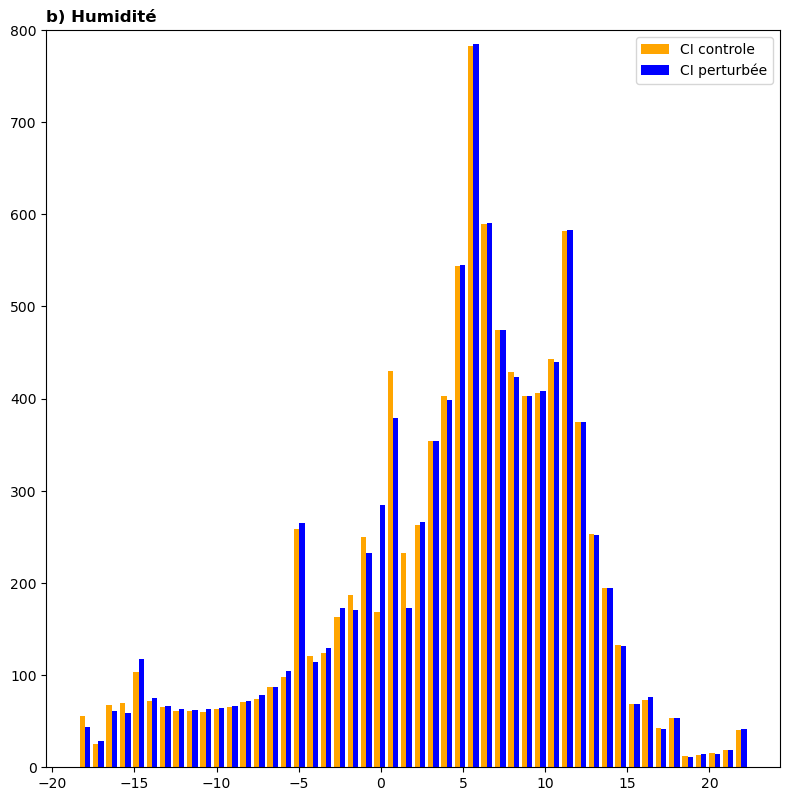

In [146]:
fig,ax=plt.subplots(figsize=(8,8))
label=['CI controle','CI perturbée']
color=['orange','blue']
ax.hist([y_list_1,y_list_2],bins=logbin_y,label=label,histtype='bar',stacked=False,color=color)
ax.set_title('b) Humidité',loc='left',fontweight='bold')
plt.legend()
ax.set_ylim(0,800)
plt.tight_layout()
plt.subplots_adjust(top=0.97)
fig.savefig('histogramme_y.png',bbox_inches='tight',dpi=500 )

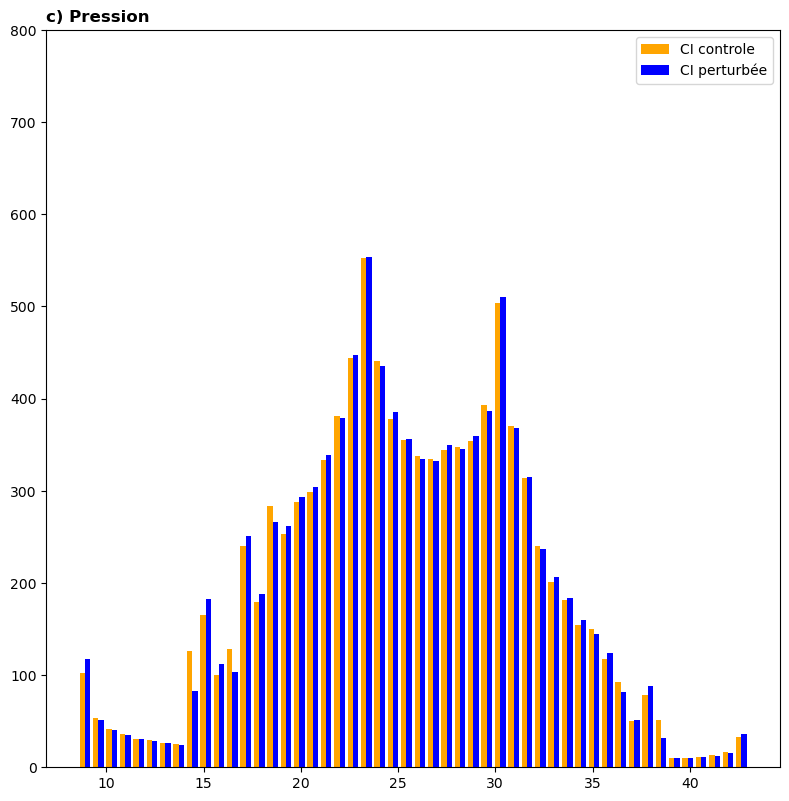

In [141]:
fig, ax = plt.subplots(figsize=(8, 8))
label=['CI controle','CI perturbée']
color=['orange','blue']
ax.hist([z_list_1,z_list_2],bins=logbin_z,label=label,histtype='bar',stacked=False,color=color)
ax.set_title('c) Pression',loc='left',fontweight='bold')
#ax.hist(z_list_1, bins=logbin_z, label='CI controle')
#ax.hist(z_list_2, bins=logbin_z, label='CI perturbée')
plt.legend()
ax.set_ylim(0,800)
plt.tight_layout()
plt.subplots_adjust(top=0.97)
fig.savefig('histogramme_z.png',bbox_inches='tight',dpi=500 )

### Exploration statistique des différences

#### Test statistique Mann-Whitney U test

In [195]:
U1, p1= stats.ks_2samp(x_list_1,x_list_2)
print('x:',p1)
U1, p1= stats.ks_2samp(y_list_1,y_list_2)
print('y:',p1)

U1, p1= stats.ks_2samp(z_list_1,z_list_2)
print('z:',p1)

x: 0.8435889342947497
y: 0.27321683386131995
z: 0.9411994973047206
